In [1]:
# Import the Product Reader from spectro module of euclidlib
from euclidlib.spectro import DpdLE3GCReader

import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
# Get the xml file name
xml_file = glob.glob("BOSS_2PCF/*.xml")[0]

In [3]:
print(xml_file)

BOSS_2PCF/EUC_LE3_GCL_2PCF_BOSS_DR12v5_CMASSLOWZTOT_North_bin1_Correlation_AUTO_2DPOL_763DCA2E6E2D_20240220T235142.0Z.xml


### Structure of the filename

- Processing function name: EUC_LE3_GCL_2PCF
- Output_prefix: BOSS_DR12v5_CMASSLOWZTOT_North_bin1
- Product Type: Correlation_AUTO_2DPOL
- Random tag: 763DCA2E6E2D
- Time stamp: 20240220T235142.0Z

In [4]:
# Initialize product reader
product = DpdLE3GCReader()

In [5]:
# Parse product xml
product.parse_xml(xml_file)

In [6]:
# List xml keywords
print(product.header_keywords)

print(product.data_keywords)

print(product.table_keywords)

dict_keys(['ProductId', 'ProductType', 'SoftwareName', 'SoftwareRelease', 'ProdSDC', 'DataSetRelease', 'Purpose', 'PlanId', 'PPOId', 'PipelineDefinitionId', 'PpoStatus', 'ManualValidationStatus', 'Curator', 'CreationDate'])
dict_keys(['DataCatalog', 'RandCatalog', 'CountingMethod', 'BinTypeDim1', 'BinNumberDim1', 'BinMinValueDim1', 'BinMaxValueDim1', 'BinTypeDim2', 'BinNumberDim2', 'BinMinValueDim2', 'BinMaxValueDim2', 'UseWeight', 'SplitFactor', 'CosmologyID', 'ReleaseName', 'LosDef'])
dict_keys(['PairsFile', 'CorrelationFile', 'CorrelationFileMultipole'])


In [7]:
# Read fits files associated to the product
product.read_tables()

In [8]:
# List all the tables
product.tables

{'Pairs_PAIRS': <euclidlib.spectro._table_reader.DpdLE3GCTable at 0x7f8c78e86ed0>,
 'Correlation_CORRELATION': <euclidlib.spectro._table_reader.DpdLE3GCTable at 0x7f8c7596f450>,
 'CorrelationMultipole_CORRELATION': <euclidlib.spectro._table_reader.DpdLE3GCTable at 0x7f8c78f25150>}

In [9]:
#Print the header of CorrelationMultipole table
product.CorrelationMultipole_CORRELATION.header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                   48 / width of table in bytes                        
NAXIS2  =                   40 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                    6 / number of fields in each row                   
EXTNAME = 'CORRELATION'        / name of this binary table extension            
DATE    = '2024-02-20T23:04:31' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
CHECKSUM= 'HbACHa09Ha7AHa79'   / HDU checksum updated 2024-02-20T23:04:31       
DATASUM = '1425714226'         / data unit checksum updated 2024-02-20T23:04:31 
TTYPE1  = 'SCALE   '        

In [10]:
# Print the CorrelationMultipole table
product.CorrelationMultipole_CORRELATION.table

,SCALE,XI0,XI1,XI2,XI3,XI4
0,2.5,5.897850,0.000000e+00,3.520355,2.664535e-15,4.636546
1,7.5,1.697924,-2.915968e-08,0.169783,1.020546e-07,0.724146
2,12.5,0.698480,-1.891653e-08,-0.173174,6.620510e-08,0.169303
3,17.5,0.364918,-1.246946e-08,-0.157882,4.364131e-08,0.044521
4,22.5,0.211347,-1.087310e-08,-0.115891,3.805425e-08,0.023924
5,27.5,0.132770,-1.317664e-08,-0.093681,4.611630e-08,0.006292
6,32.5,0.087902,-1.276070e-08,-0.072486,4.466060e-08,0.004092
7,37.5,0.060313,-1.052952e-08,-0.058517,3.685177e-08,0.001317
8,42.5,0.042299,-1.024090e-08,-0.046194,3.584164e-08,0.001908
9,47.5,0.030075,-1.022509e-08,-0.034962,3.578631e-08,0.001483


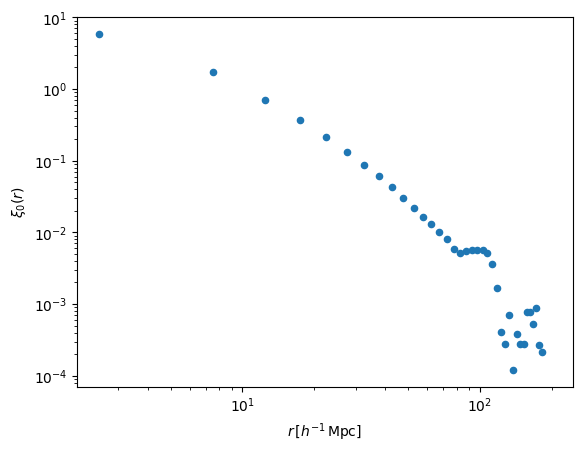

In [11]:
# Plot the correlation table with built-in functions

ax = product.plot("CorrelationMultipole_CORRELATION", x="SCALE", y="XI0")

ax.set_xlabel(r"$r \, [h^{-1} \, \mathrm{Mpc}]$")
ax.set_ylabel(r"$\xi_0(r)$")

ax.set_xscale("log")
ax.set_yscale("log")

Text(0.5, 1.0, 'BOSS DR12 - $0.2 < z < 0.5$')

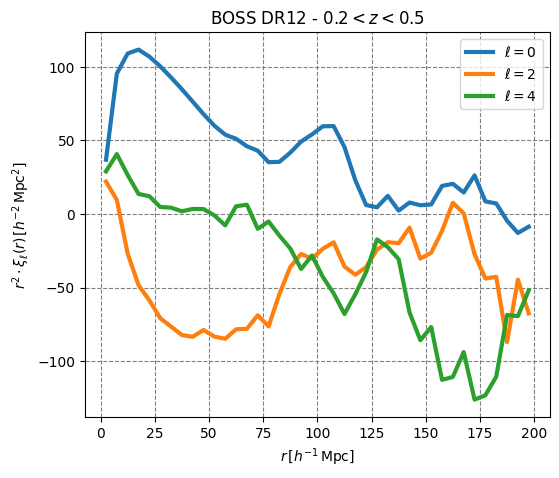

In [12]:
# Customize the plot
figure, ax = plt.subplots(1, 1, figsize=(6, 5))

for i in range(3):
    ax.plot(product.CorrelationMultipole_CORRELATION.table["SCALE"],
            product.CorrelationMultipole_CORRELATION.table["SCALE"]**2*product.CorrelationMultipole_CORRELATION.table[f"XI{2*i}"],
            label=rf"$\ell={2*i}$",
            lw = 3)

ax.set_xlabel(r"$r \, [h^{-1} \, \mathrm{Mpc}]$")
ax.set_ylabel(r"$r^2 \cdot \xi_{\ell}(r) \, [h^{-2} \, \mathrm{Mpc}^2]$")
ax.grid(True, ls="--", color="0.5")

plt.legend(loc="best")

plt.title(r"BOSS DR12 - $0.2 < z < 0.5$")